In [165]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [166]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [167]:
df = pd.read_sql(""" 
SELECT uid, timestamp FROM checker 
WHERE uid LIKE "user_%"
""", conn)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['hour'] = df['timestamp'].dt.hour

In [168]:
df.head()

,uid,timestamp,day_of_week,hour
0,user_4,2020-04-17 05:19:02.744528,4,5
1,user_4,2020-04-17 05:22:35.249331,4,5
2,user_4,2020-04-17 05:22:45.549397,4,5
3,user_4,2020-04-17 05:34:14.691200,4,5
4,user_4,2020-04-17 05:34:24.422370,4,5


In [169]:
df_commit = df.groupby(['uid', 'day_of_week'])['timestamp'].size().reset_index(name='commits')

df_hour = df.groupby(['uid', 'hour'])['timestamp'].size().reset_index(name='commits')

In [170]:
df_commit.head()

,uid,day_of_week,commits
0,user_0,0,3
1,user_1,2,1
2,user_1,3,39
3,user_1,5,1
4,user_1,6,43


In [171]:
user_totals = df_commit.groupby('uid')['commits'].sum().reset_index(name='total_commits').sort_values(by='total_commits', ascending=False)

user_totals.head()

,uid,total_commits
26,user_4,368
6,user_14,259
12,user_2,235
18,user_25,233
11,user_19,176


In [172]:
pivot_weekday = (
    df_commit.pivot(index='day_of_week', columns='uid', values='commits')
    .reindex(columns=user_totals['uid'].tolist()) 
    .fillna(0)
)

pivot_weekday

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
day_of_week,,,,,,,,,,,,,,,,,,,,,
0,35.0,50.0,24.0,14.0,7.0,0.0,23.0,5.0,0.0,46.0,...,8.0,10.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,3.0
1,86.0,87.0,131.0,44.0,9.0,1.0,0.0,0.0,16.0,11.0,...,4.0,5.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0
2,33.0,0.0,32.0,15.0,0.0,34.0,8.0,0.0,37.0,0.0,...,1.0,0.0,0.0,0.0,4.0,0.0,3.0,0.0,0.0,0.0
3,108.0,17.0,4.0,40.0,78.0,51.0,96.0,7.0,77.0,7.0,...,17.0,14.0,15.0,5.0,2.0,0.0,0.0,2.0,6.0,0.0
4,61.0,0.0,0.0,10.0,10.0,2.0,7.0,35.0,1.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,79.0,31.0,66.0,21.0,16.0,3.0,90.0,4.0,3.0,...,32.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0
6,45.0,26.0,13.0,44.0,51.0,69.0,28.0,7.0,2.0,8.0,...,0.0,31.0,27.0,20.0,9.0,8.0,0.0,1.0,0.0,0.0


In [173]:
pivot_weekday.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 0 to 6
Data columns (total 30 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_4   7 non-null      float64
 1   user_14  7 non-null      float64
 2   user_2   7 non-null      float64
 3   user_25  7 non-null      float64
 4   user_19  7 non-null      float64
 5   user_26  7 non-null      float64
 6   user_20  7 non-null      float64
 7   user_31  7 non-null      float64
 8   user_10  7 non-null      float64
 9   user_3   7 non-null      float64
 10  user_29  7 non-null      float64
 11  user_13  7 non-null      float64
 12  user_28  7 non-null      float64
 13  user_24  7 non-null      float64
 14  user_12  7 non-null      float64
 15  user_8   7 non-null      float64
 16  user_1   7 non-null      float64
 17  user_21  7 non-null      float64
 18  user_30  7 non-null      float64
 19  user_18  7 non-null      float64
 20  user_17  7 non-null      float64
 21  user_16  7 non-null      

In [174]:
pivot_hour = df_hour.pivot(index='hour',columns='uid',values='commits').fillna(0).reindex(columns=user_totals['uid'].tolist()) 

In [175]:
pivot_hour.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 0 to 23
Data columns (total 30 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_4   22 non-null     float64
 1   user_14  22 non-null     float64
 2   user_2   22 non-null     float64
 3   user_25  22 non-null     float64
 4   user_19  22 non-null     float64
 5   user_26  22 non-null     float64
 6   user_20  22 non-null     float64
 7   user_31  22 non-null     float64
 8   user_10  22 non-null     float64
 9   user_3   22 non-null     float64
 10  user_29  22 non-null     float64
 11  user_13  22 non-null     float64
 12  user_28  22 non-null     float64
 13  user_24  22 non-null     float64
 14  user_12  22 non-null     float64
 15  user_8   22 non-null     float64
 16  user_1   22 non-null     float64
 17  user_21  22 non-null     float64
 18  user_30  22 non-null     float64
 19  user_18  22 non-null     float64
 20  user_17  22 non-null     float64
 21  user_16  22 non-null   

In [178]:
pivot_hour.head()

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


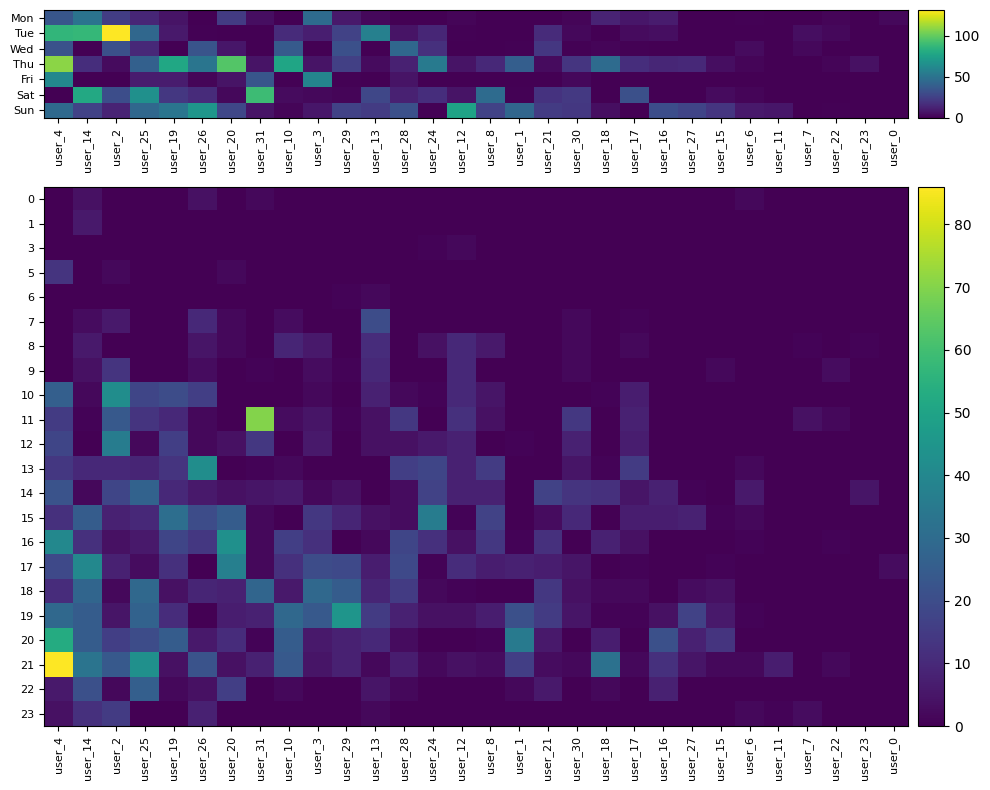

In [156]:
cmap = 'viridis'

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 5]})

# heatmap по дням недели
im1 = axes[0].imshow(pivot_weekday.values, aspect='auto', cmap=cmap)
axes[0].set_yticks(range(len(pivot_weekday.index)))
axes[0].set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=8)
axes[0].set_xticks(range(len(pivot_weekday.columns)))
axes[0].set_xticklabels(pivot_weekday.columns, rotation=90, fontsize=8)

divider1 = make_axes_locatable(axes[0])
cax1 = divider1.append_axes("right", size="3%", pad=0.1)
plt.colorbar(im1, cax=cax1)

# heatmap по часам
im2 = axes[1].imshow(pivot_hour.values, aspect='auto', cmap=cmap)

axes[1].set_yticks(range(len(pivot_hour.index)))
axes[1].set_yticklabels(pivot_hour.index, fontsize=8)  # реальные индексы
axes[1].set_xticks(range(len(pivot_hour.columns)))
axes[1].set_xticklabels(pivot_hour.columns, rotation=90, fontsize=8)

divider2 = make_axes_locatable(axes[1])
cax2 = divider2.append_axes("right", size="3%", pad=0.1)
plt.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()

In [157]:
conn.close()

«Какой пользователь имеет больше всего коммитов во вторник?» 
- Ответ: user_2.


«Какой пользователь имеет больше всего коммитов в Чт?» 
- Ответ: user_20.


«В какой день недели пользователи не любят делать много коммитов?» 
- Ответ: Пятница


«Какой пользователь в какой час сделал наибольшее количество коммитов?» 
- Ответ: user_4, 21